In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# 경사 하강법
- 미분 가능한 목적함수의 값을 줄이기 위해 음의 기울기 방향으로 변수를 반복 갱신
- $$\mathbf x = <x_1, x_2 \cdots, x_n>$$
- $$\mathbf x \leftarrow \mathbf x - \eta \nabla f(\mathbf x)$$
- $$x_i \leftarrow  x_i - \eta \frac{\partial f}{ \partial x_i}$$

In [ ]:
def num_grad(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)  # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x)  # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2 * h)

        x[idx] = tmp_val  # 값 복원
        it.iternext()

    return grad


def grad_dsc(f, init_x, lr=0.01, step_num=100):
    x = init_x
    steps = np.array([x.copy()])

    for _ in range(step_num):
        grad = num_grad(f, x)
        x -= lr * grad
        steps = np.vstack((steps, x.copy()))
    return steps

In [17]:
def func_1(x):
    return x[0] **2 + x[1] ** 2

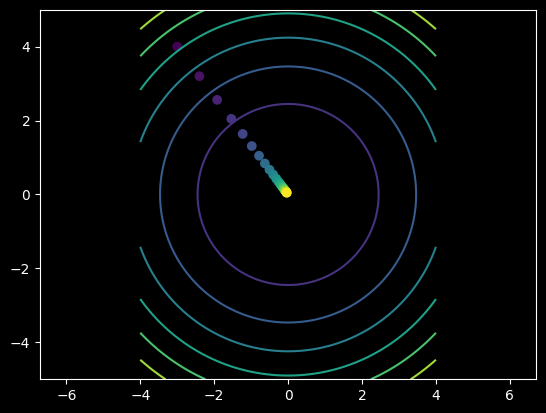

In [85]:
steps = grad_dsc(func_1, init_x=np.array([-3.0, 4.0]), lr=0.1, step_num=20)

x_max = max(abs(steps[:, 0].min()), abs(steps[:, 0].max())) + 1
y_max = max(abs(steps[:, 1].min()), abs(steps[:, 1].max())) + 1
x = np.linspace(-x_max, x_max, 200)
y = np.linspace(-y_max, y_max, 200)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2
plt.contour(X, Y, Z)

plt.scatter(steps[:, 0], steps[:, 1], c=np.arange(len(steps)), cmap="viridis")

plt.axis("equal")
plt.show()

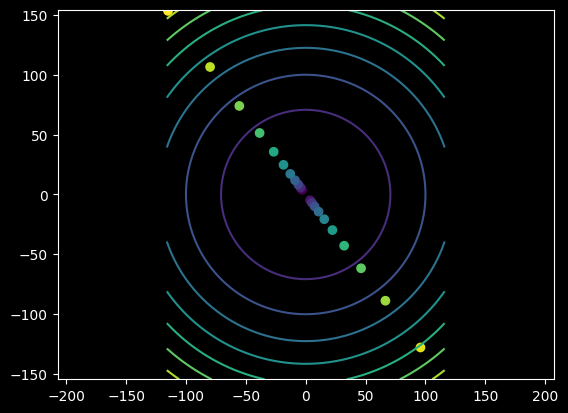

In [86]:
steps = grad_dsc(func_1, init_x=np.array([-3.0, 4.0]), lr=1.1, step_num=20)

x_max = max(abs(steps[:, 0].min()), abs(steps[:, 0].max())) + 1
y_max = max(abs(steps[:, 1].min()), abs(steps[:, 1].max())) + 1
x = np.linspace(-x_max, x_max, 200)
y = np.linspace(-y_max, y_max, 200)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2
plt.contour(X, Y, Z)

plt.scatter(steps[:, 0], steps[:, 1], c=np.arange(len(steps)), cmap="viridis")

plt.axis("equal")
plt.show()

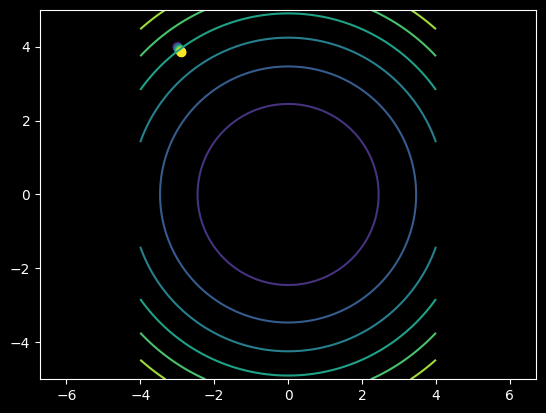

In [64]:
steps = grad_dsc(func_1, init_x=np.array([-3.0, 4.0]), lr=0.001, step_num=20)

x_max = max(abs(steps[:, 0].min()), abs(steps[:, 0].max())) + 1
y_max = max(abs(steps[:, 1].min()), abs(steps[:, 1].max())) + 1
x = np.linspace(-x_max, x_max, 200)
y = np.linspace(-y_max, y_max, 200)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2
plt.contour(X, Y, Z)

plt.scatter(steps[:, 0], steps[:, 1], c=np.arange(len(steps)), cmap="viridis")

plt.axis("equal")
plt.show()

## 신경망에서 경사 하강법
- 모델 $f(\mathbf x; W)$에서 로스 $L(f(\mathbf x; W), y)$를 $W$에 대해 경사 하강법 적용
- $$W \leftarrow W - \eta \nabla_W L(f(\mathbf x; W), \mathbf y)$$

In [92]:
from b1.module import SimpleNet

net = SimpleNet()

x = np.array([0.6, 0.9])
t = np.array([0, 0, 1])
net.predict(x), net.loss(x, t)

(array([1.09695608, 1.3328317 , 1.71018291]), np.float64(0.8007789181227827))

In [97]:
f = lambda w: net.loss(x, t)
dW = num_grad(f, net.W)